# **Exploratory Data Analysis of Telecom Customer Churn**

##**Problem Statement**

The Telecom Industry experiences high customer churn, making it critical to understand **why customers leave**. This EDA aims to indentify key **patterns , trends, and factors** influencing churn by analyzing customer **demographics, services, billing details, and account information**. The goal is to uncover **actionable insights** that help improve **customers retention** and support **future churn prediction** models.

## **Objecttives**


*   Analyze key features such as **demograpics, services, billing, and account** details that influence customer churn.
*   Uncover important patterns, correlations, and trends using EDA.

*   Provide actionable insights to improve customer retention strategies.





#### **Importing Libraries**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### **Load Data**

In [5]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### **Data Description**

The dataset contains **customer infromation** from a **telecom company**, including **demograpics, services subscriptions, account** details, billing information, and **churn flag** indication whether a **customer has left the service**. It helps analyze **customer behaviour** and identify key factors contributing to **customer churn**.

**customerID** - Unique identifier assigned to each customer.

**gender** - Customer's gender(Male/Female).

**SeniorCitizen**- Indicates if the customer is a senior citizen(0=No, 1=Yes).

**Partner** - Whether the customer has a partner(Yes/No).

**Dependents** - Whether the customer has dependents(Yes/No).

**tenure** - Number of months the customer has stayed with the company.

**PhoneService** - Indicates if the customer has phone service(Yes/No).

**MultipleLines** - Availability of multiple phone lines.

**InternetService** - Type of internet service (DSL, Optic Fiber, No)

**OnlineSecurity** - Online security service status.

**OlineBackup** - Online backup service status.

**DeviceProtection** - Device protection plan status.

**TechSupport** - Technical support service status.

**StreamingTV** - Access to streaming TV service.

**StreamingMovies** - Access to streaming movies.

**Contract** - Customer's contract type(Month-to-Month/One Year/Two Year)

**PaperlessBilling** - Indicates if customers uses paperless billing(Yes/No)

**PaymentMethod** - Customer's mode of payment.

**MonthlyCharges** - Monthly charges billed to the customer.

**TotalCharges** - Total charges incurred by the customer.

**Churn** - indicates whether the customer has discontinued the service(Yes/No).


#### **Dataset Information**

In [12]:
# Shape
print(f'Number of Rows in the dataset :',df.shape[0])
print(f'Number of Columns in the dataset :',df.shape[1])

Number of Rows in the dataset : 7043
Number of Columns in the dataset : 21


In [13]:
# Columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
# Data Types
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [17]:
# Duplicate Values
print(f'Duplicate Values in dataframe : ', df.duplicated().sum())

Duplicate Values in dataframe :  0


In [18]:
# Missing/Null Values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
# number columns
num_col = df.select_dtypes(include=np.number).columns
num_col

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [21]:
# categorical columns
cat_col = df.select_dtypes(include='object').columns
cat_col

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [25]:
# Describe
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [26]:
# Describe with object columns
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [31]:
# Check unique values for each variable
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [29]:
for x in df.columns:
  print(x)
  print(df[x].unique())
  print()

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

SeniorCitizen
[0 1]

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'

In [33]:
# Replace empty or other strings in dataframe with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

In [37]:
# Changing Data Types
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [39]:
df['TotalCharges'].isnull().sum()

np.int64(11)

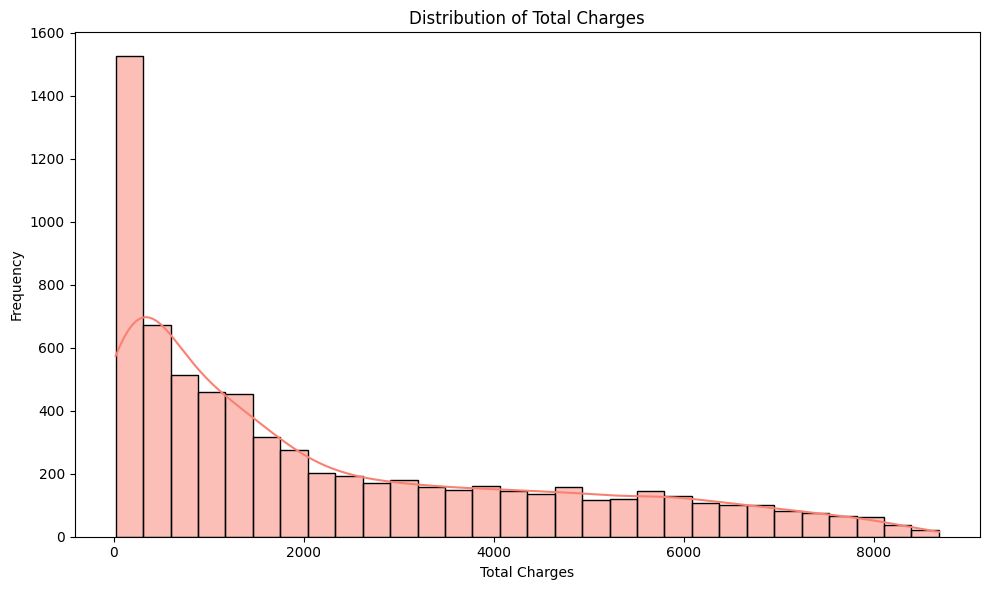

In [41]:
# Checking the distribution of 'TotalCharges'
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalCharges'], bins=30, color='salmon', kde=True)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [42]:
# Because distribution is skewed, replace NaN with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [43]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [50]:
# Add column Churn_no(1 if Yes, 0 if No)
df['Churn_no'] = (df['Churn'] == 'Yes').astype(int)

### **KPIs**

In [47]:
# General Content Overview as KPIs
total_coustemers = df['customerID'].nunique()
male = df[df['gender'] == 'Male'].shape[0]
female = df[df['gender'] == 'Female'].shape[0]
avg_tenure = df['tenure'].mean().round(2)
avg_monthly_charges = df['MonthlyCharges'].mean().round(2)
avg_total_charges = df['TotalCharges'].mean().round(2)

print(f'Total Customers : {total_coustemers}')
print(f'Male Customers : {male}')
print(f'Female Customers : {female}')
print(f'Average Tenure : {avg_tenure}')
print(f'Average Monthly Charges : {avg_monthly_charges}')
print(f'Average Total Charges : {avg_total_charges}')

Total Customers : 7043
Male Customers : 3555
Female Customers : 3488
Average Tenure : 32.37
Average Monthly Charges : 64.76
Average Total Charges : 2281.92


In [49]:
# Average 'TotalCharges' by 'PaymentMethod'
print('Average Total Charges by Payment Method:')
df.groupby('PaymentMethod')['TotalCharges'].mean().round(2)

Average Total Charges by Payment Method:


,TotalCharges
PaymentMethod,
Bank transfer (automatic),3077.12
Credit card (automatic),3070.30
Electronic check,2090.87
Mailed check,1056.19


## **Data Visualization, Storytelling & Experimenting with charts: understand the relationship between variables**

### 1. What is the distribution of Churn(Yes/No)?

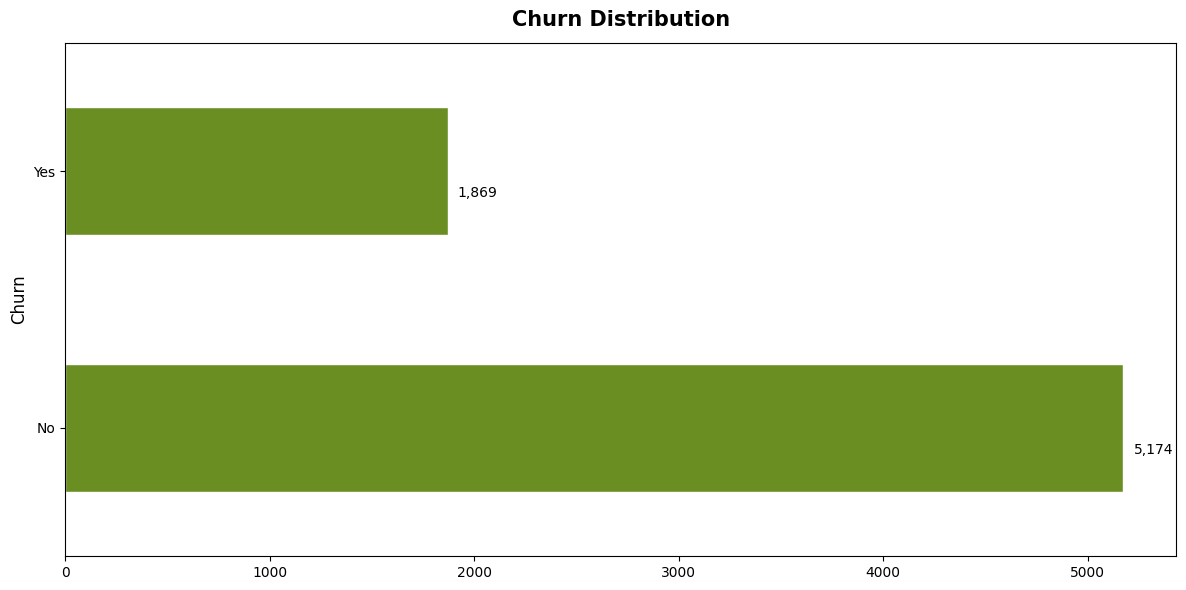

In [56]:
#Plotting the data
plt.figure(figsize=(12, 6))

df['Churn'].value_counts().plot(kind='barh', color='olivedrab', edgecolor='white')
plt.title('Churn Distribution', pad=12, fontsize=15, fontweight='bold')
plt.ylabel('Churn', fontsize=12)

for index, value in enumerate(df['Churn'].value_counts()):
    label = format(int(value), ',')
    plt.annotate(label, xy=(value + 50, index - 0.10), color='black' )

plt.tight_layout()
plt.show()

### **Insights**

**Customer Retention:** A large proportion of customers continue using the service, indicating relatively strong retention.

**Churn Rate:** A significant portion of customers have churned, which suggests areas for improvement in customer satisfaction or service quality.

**Opportunity for Improvement:** Reducing the churn rate could lead to better customer loyalty and more stable revenue streams.

**Actionable Insight:** The company could benefit from targeted efforts to understand and address the reasons behind the churn.

### 2. How many customers fall under each Contract Type?

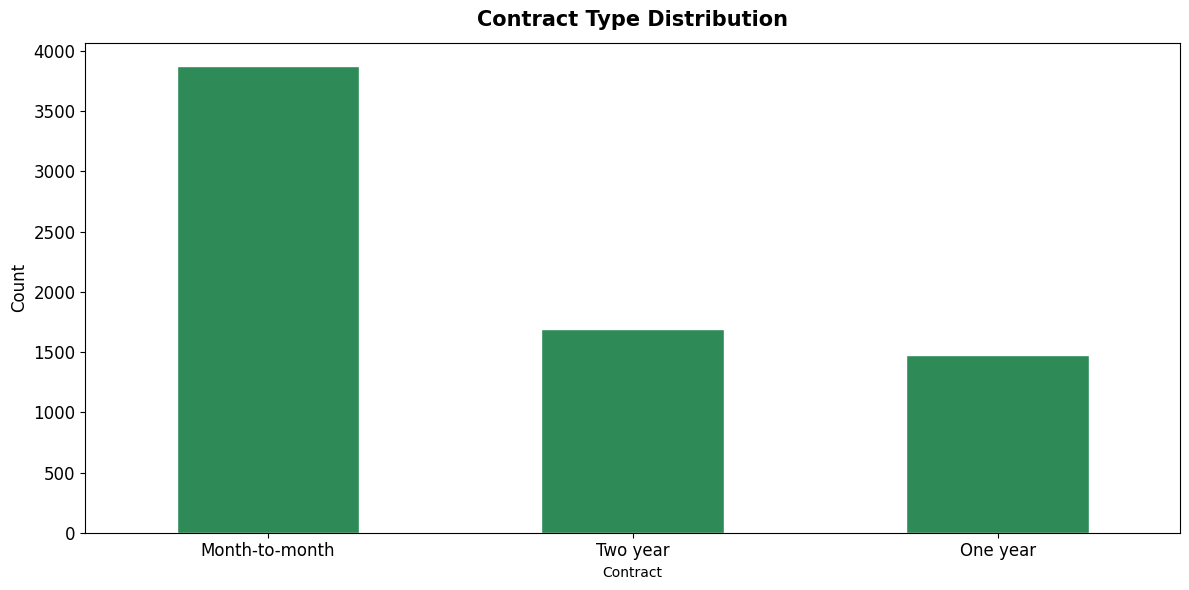

In [68]:
#Plotting the data
plt.figure(figsize=(12, 6))

df['Contract'].value_counts().plot(kind='bar', color='seagreen', edgecolor='white')
plt.title('Contract Type Distribution', pad=12, fontsize=15, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='center', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## **Insights**

**Most customers are on Month-to-Month contracts -** This is the largest category, with over 3500 customers.

**Fewer customers have One-Year and Two-Year contracts -** These types have a relatively small proportion.

**Opportunity -** The company might focus on converting Month-to-Month customers into longer-term contracts to improve retention and reduce churn.

### 3. What is the distribution of Internet Service Types?

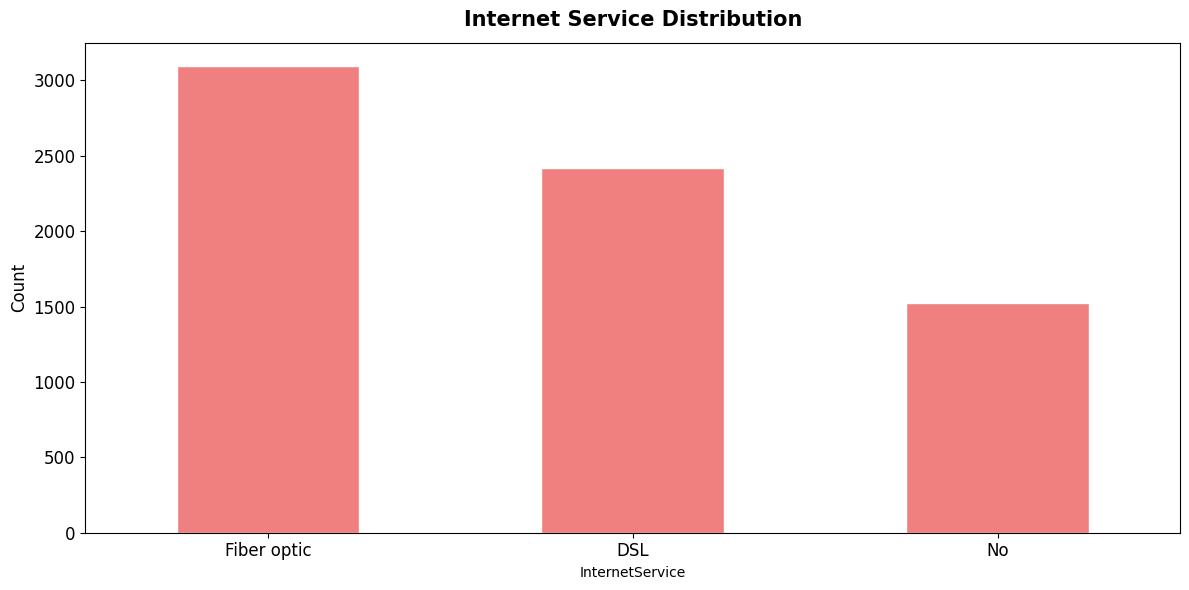

In [70]:
#Plotting the data
plt.figure(figsize=(12, 6))

df['InternetService'].value_counts().plot(kind='bar', color='lightcoral', edgecolor='white')
plt.title('Internet Service Distribution', pad=12, fontsize=15, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='center', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## **Insights**

**Most Customers use Fiber Optic -** The highest number of customers have chosen Fiber optic internet.

**DSL is also popular -** DSL is the second most common service type among customers.

**Few customers do not have internet -** A relatively small number of customers have no internet service.

### 4. How is the tenure distribution among customers?

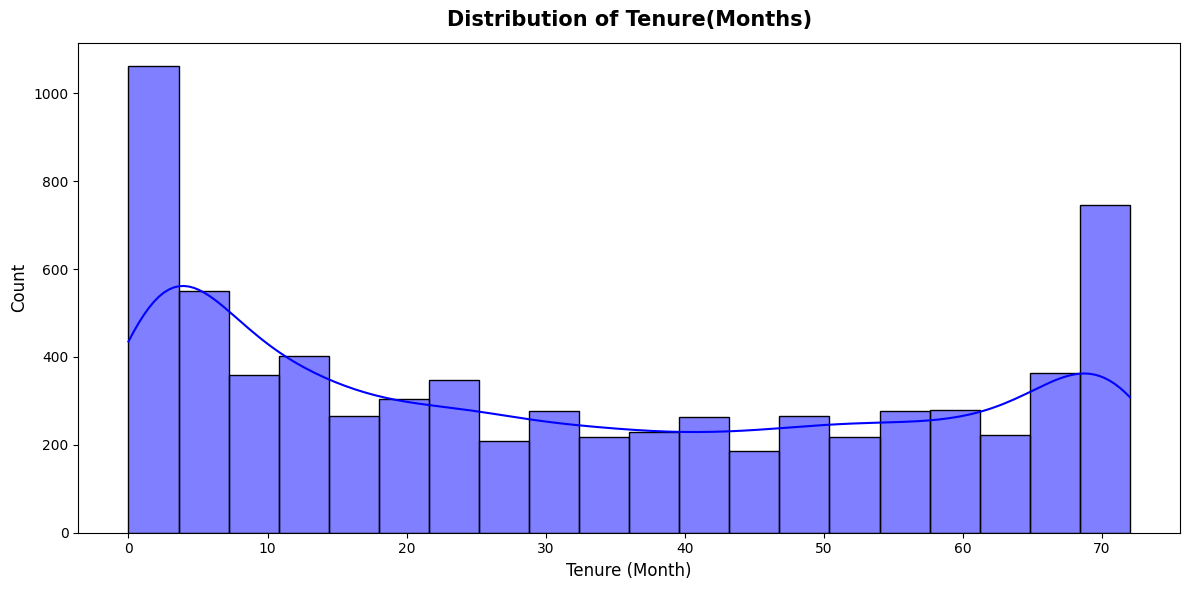

In [74]:
# Plotting the data
plt.figure(figsize=(12, 6))

sns.histplot(df['tenure'], bins=20, kde=True, color='blue')
plt.title('Distribution of Tenure(Months)', pad=12, fontsize=15, fontweight='bold')
plt.xlabel('Tenure (Month)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

## **Insights**

**High chrun among new Customers -** There is a sharp peak in the 0-5 months range, suggesting that many customers leave early.

**Stable retention anong long-term customers -** After the initial churn, customer retention appears more consistent, with more stable counts in the 20-60 month range.

**Potential focus on early retenton strategies -** The company may benefit from implementing retention programs targeted at new customers to reduce early churn.

### 5. What is the distribution of Monthly Charges?

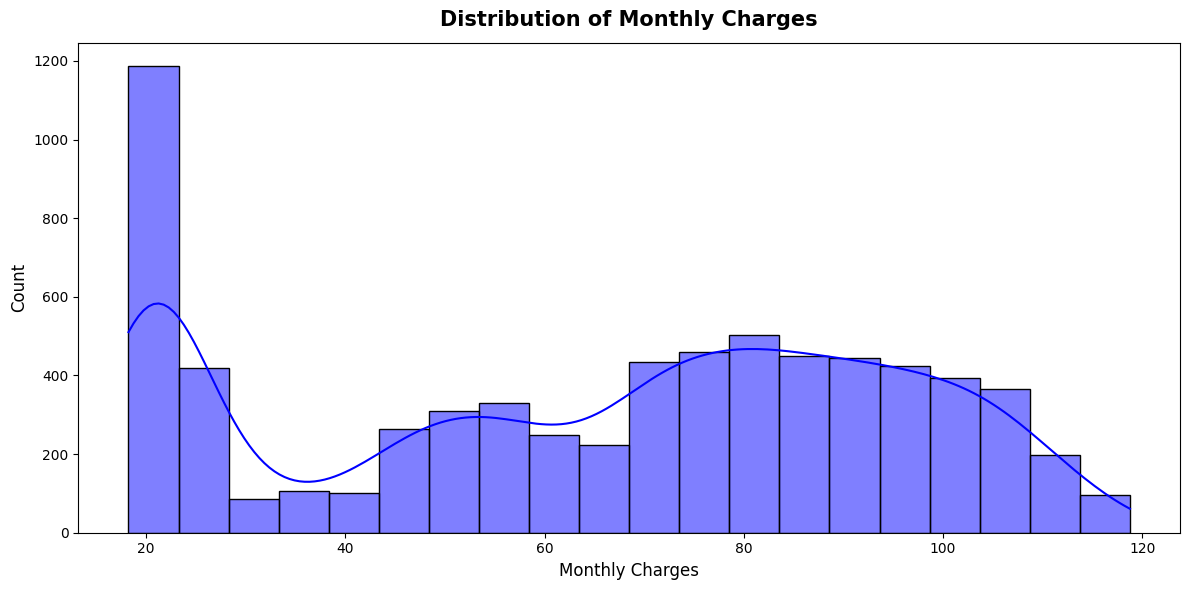

In [76]:
# Plotting the data
plt.figure(figsize=(12, 6))

sns.histplot(df['MonthlyCharges'], bins=20, kde=True, color='blue')
plt.title('Distribution of Monthly Charges', pad=12, fontsize=15, fontweight='bold')
plt.xlabel('Monthly Charges', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

## **Insights**

**Most customer are charged around 20 per month -** There is a significant peak at $20 mark, indicating a large number of low-cost plans.

**The distribution is slightly right-skewed -** Although most customers are in the lower monthly charge range, there are customers with higher charges as well.

**Opportunities for segmentation -** The company could consider segmenting customers by pricing tiers for tailored retention strategies.

### 6. What is the distribution of Total Charges?

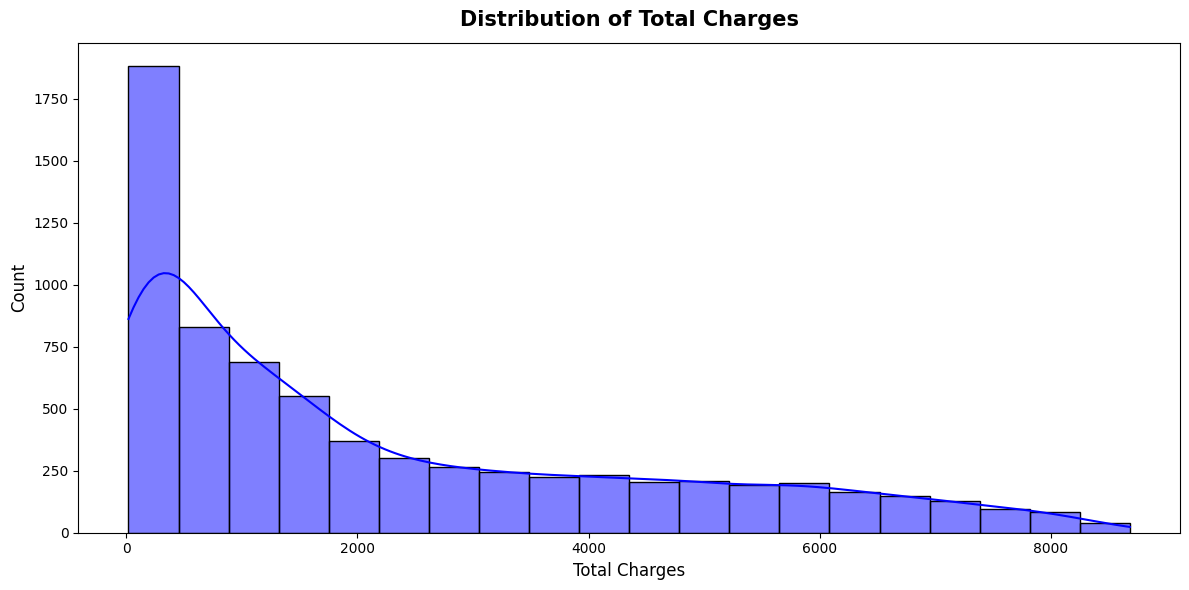

In [78]:
# Plotting the data
plt.figure(figsize=(12, 6))

sns.histplot(df['TotalCharges'], bins=20, kde=True, color='blue')
plt.title('Distribution of Total Charges', pad=12, fontsize=15, fontweight='bold')
plt.xlabel('Total Charges', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

## **Insights**

**High consentration of low total charges -** Most customers have low total charges, as indicated by the peak near 0 to 1000.

**Right-skewed distribution -** The total charges distribution is skewed right, meaning a few customers have significantly higher charges, but most customers fall into lower total charges.

**Potential for tiered pricing strategies -** The company could consider focusing on higher charge tiers for upselling or retention offers to high-value customers.

### 7. How does churn vary accross different contract types?

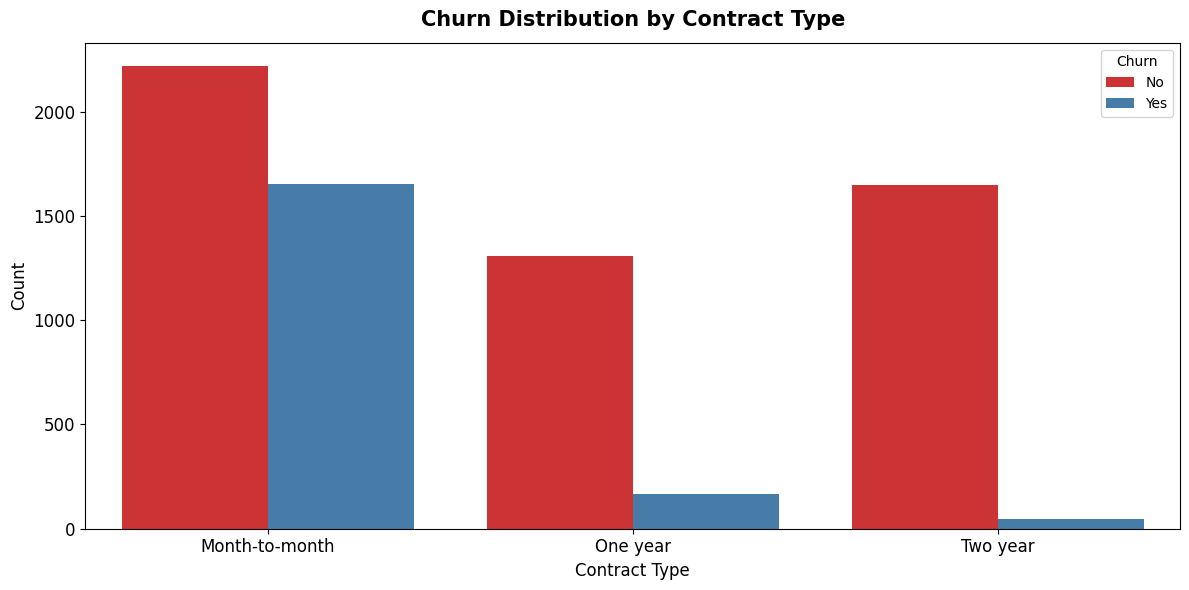

In [87]:
# Plotting the data
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Churn Distribution by Contract Type', pad=12, fontsize=15, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## **Insights**

**High churn for Month-to-Month contracts -** Customers with Month-to-Month contracts have the highest churn rate, indicating that customers with flexible, short-term contracts are more likely to leave.

**Lower churn for One-Year and Two-Year contracts -** Customers with One Year and Two Year contracts show signifantly lower churn, suggesting that longer commitment contracts help in retention.

**Opportunity for retention strategies -** Focusing on converting Month-to-Month customers to longer contracts could reduce churn.

### 8. How does churn differ among internet service types?

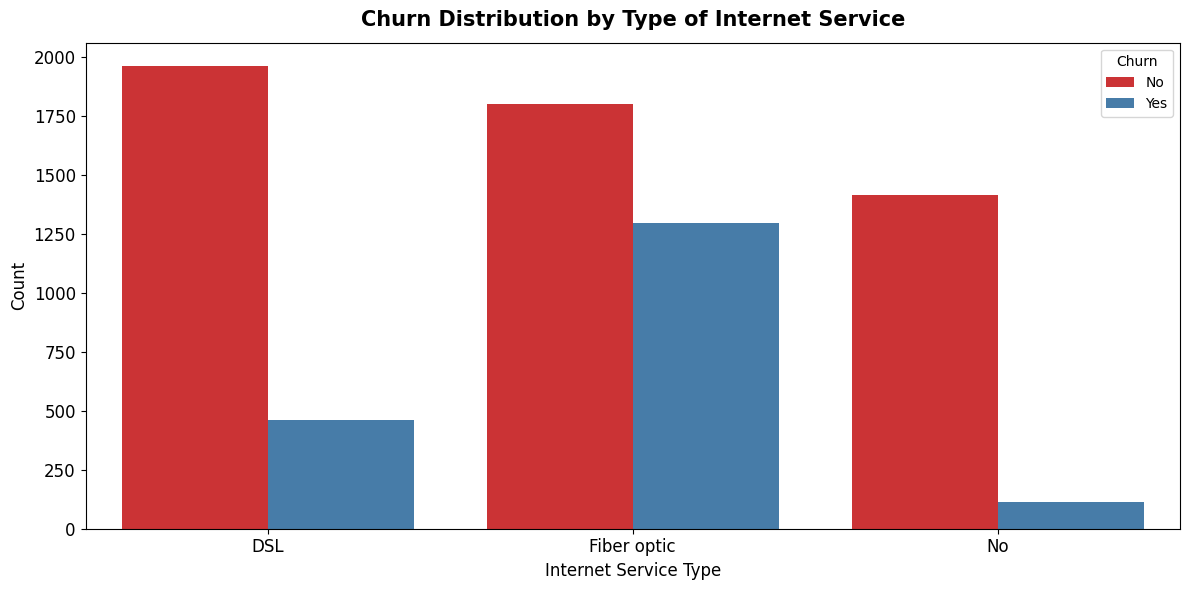

In [88]:
# Plotting the data
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set1')
plt.title('Churn Distribution by Type of Internet Service', pad=12, fontsize=15, fontweight='bold')
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

### **Insights**

**Higher churn for Fiber Optic users -** Customers using Fiber optic internet have the highest churn rate, suggesting potential dissatisfaction with this service.

**DSL users shows lower churn -** Customers using DSL internet service exhibit ower churn, possibly due to greater satisfaction or lower expection.

**Opportunity to improve Fiber Optoic service -** The company could explore customer feedback and issues related to Fiber Optic service to reduce churn in this segment.

### 9. How does churn vary accross different payment methods?

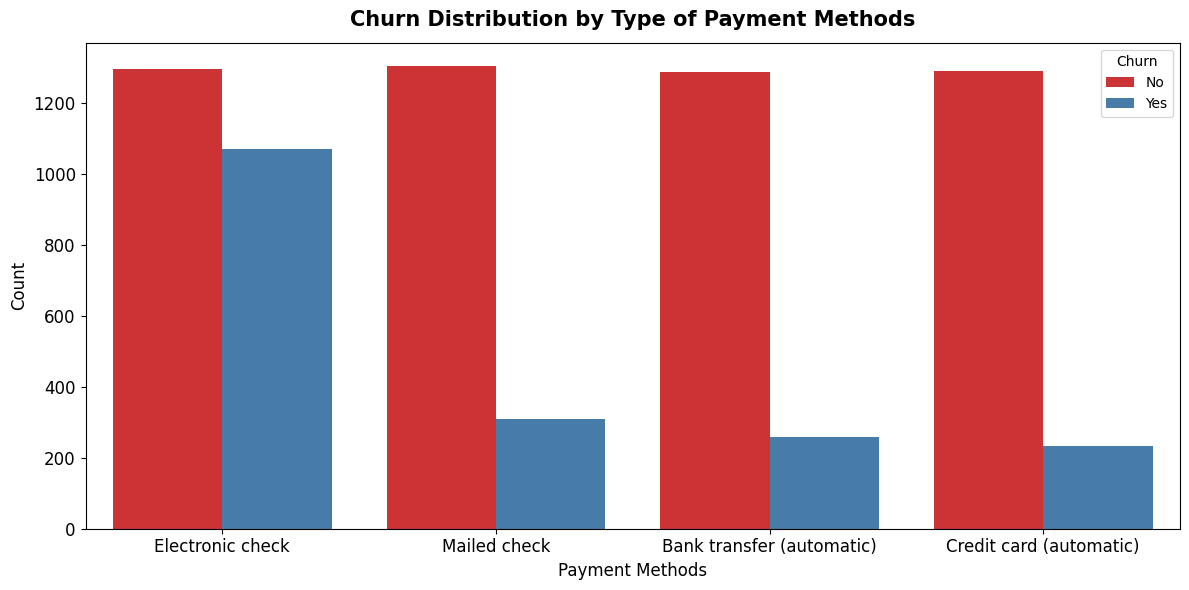

In [90]:
# Plotting the data
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set1')
plt.title('Churn Distribution by Type of Payment Methods', pad=12, fontsize=15, fontweight='bold')
plt.xlabel('Payment Methods', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

### **Insights**

**Highest churn with Electronic Check -** Customers who use Electronic Check as a payment method have the highest churn rate.

**Lower churn with Autometic Bank Transfers and Credit Cards -** Customers using Bank Transfer(automatic) or credit card(Autometic) methods show significantly lower churn.

**Opportunity for retention -** The company could focus on Electronic Check users by offering incentives or improving the payment process to reduce churn.

### 10. Do Monthly Charges differ between churn and non-churned customers?

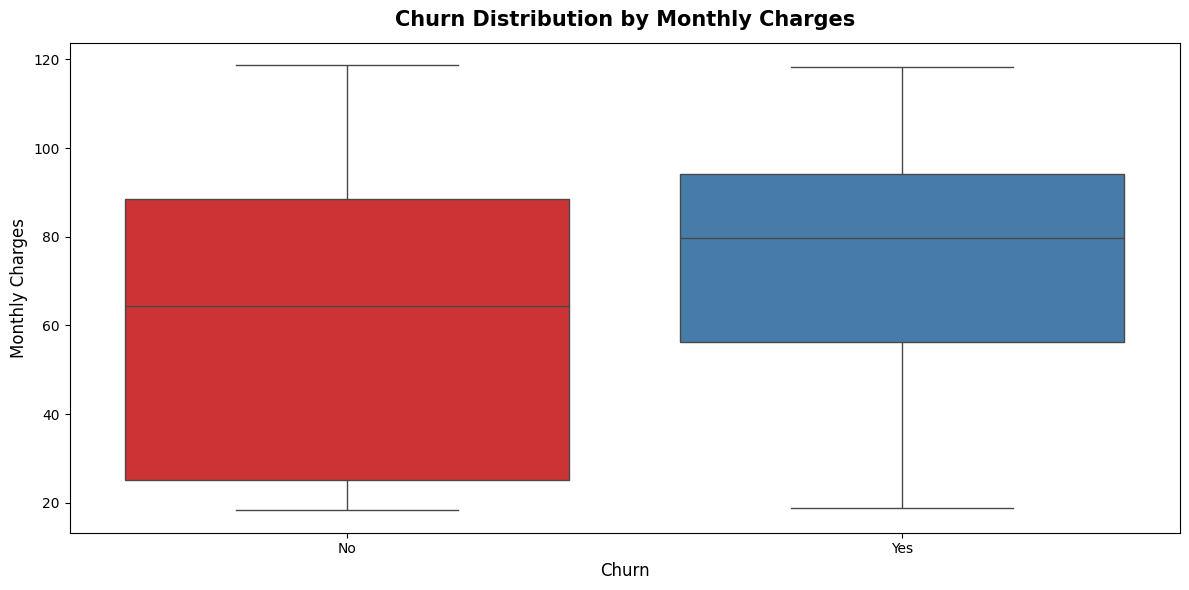

In [102]:
# Plotting the data
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='Churn' ,y='MonthlyCharges', palette='Set1')
plt.title('Churn Distribution by Monthly Charges', pad=12, fontsize=15, fontweight='bold')
plt.ylabel('Monthly Charges', fontsize=12)
plt.xlabel('Churn', fontsize=12)

plt.tight_layout()
plt.show()

### **Insights**

**Higher Monthly Charges for Churned Customers -** Customers who have churned tend to have higher monthly charges compared to those who stayed.

**Wider range of charges for churned customers -** The box plot shows a larger spread for churned customers, indicating variability in monthly charges for those who left.

**Opportunity for targeted retention strategies -** The company could explore offering lower-cost plans or incentives to high-paying customers to reduce churn.

### 11. Are customers with dependents less likely to churn?

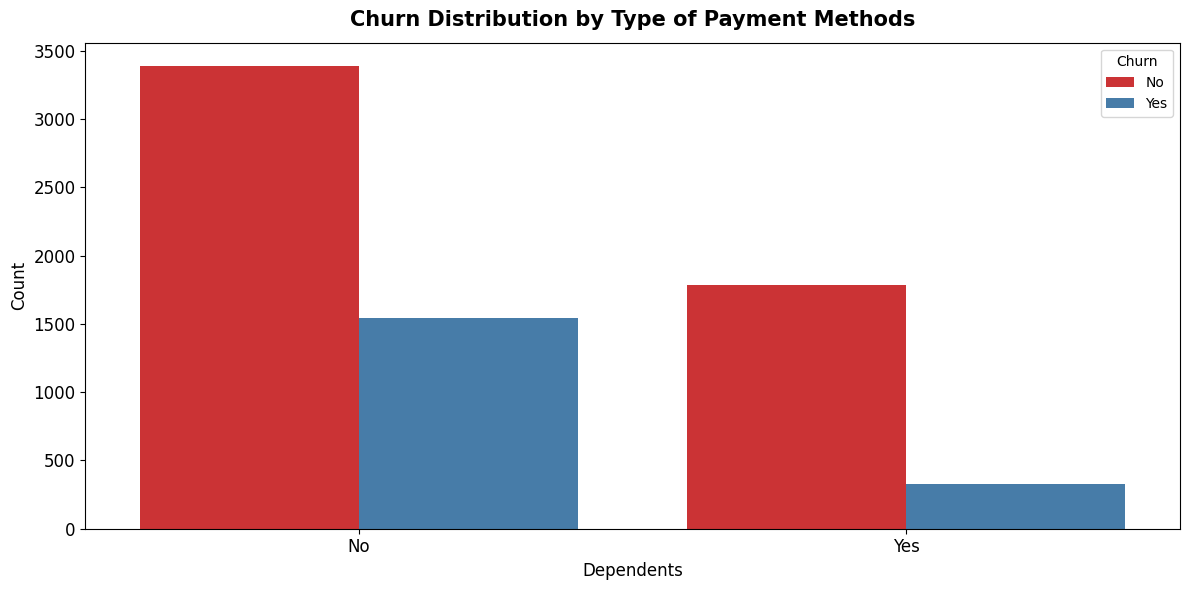

In [104]:
# Plotting the data
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='Dependents', hue='Churn', palette='Set1')
plt.title('Churn Distribution by Type of Payment Methods', pad=12, fontsize=15, fontweight='bold')
plt.xlabel('Dependents', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

### **Insights**

**Higher churn among customers without dependents -** Customers without dependents show higher churn compared to those with dependents.

**Lower churn for customers with dependents -** Customers with dependents tend to have lower churn rate, possibly due to family-related commitments.

**Opportunity for targeted retention -** The company could focus more on retaining non-dependent customers with personalized offers or services.

### 12. Are customers without tech support more likely to churn?

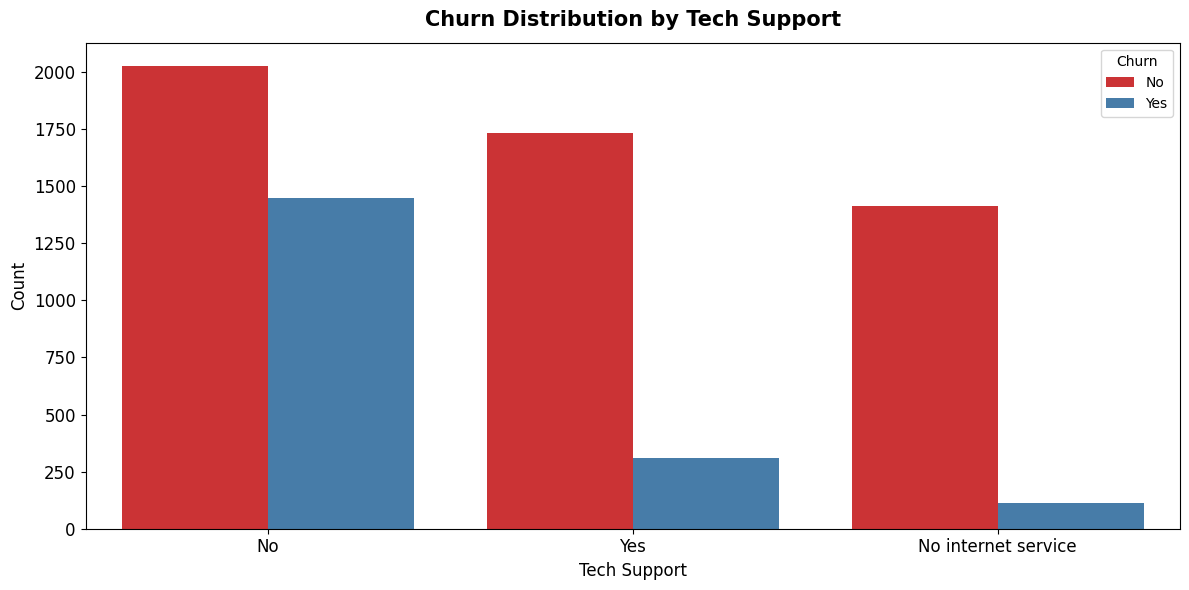

In [106]:
# Plotting the data
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='TechSupport', hue='Churn', palette='Set1')
plt.title('Churn Distribution by Tech Support', pad=12, fontsize=15, fontweight='bold')
plt.xlabel('Tech Support', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

### **Insights**

**Higher churn for customer without Tech Support -** Customers who do not have Tech Support are more likely to churn.

**Lower churn for customer with Tech Support -** Customers with Tech Suport tend to stay longer, showing a lower churn rate.

**Opportunity for improveing Support -** Offering or improving Tech Support could be an effictive startegy to reduce churn, specially among customers who currently do not have it.

### 13. How does Internet Service, Monthly Charges, and Churn interact?

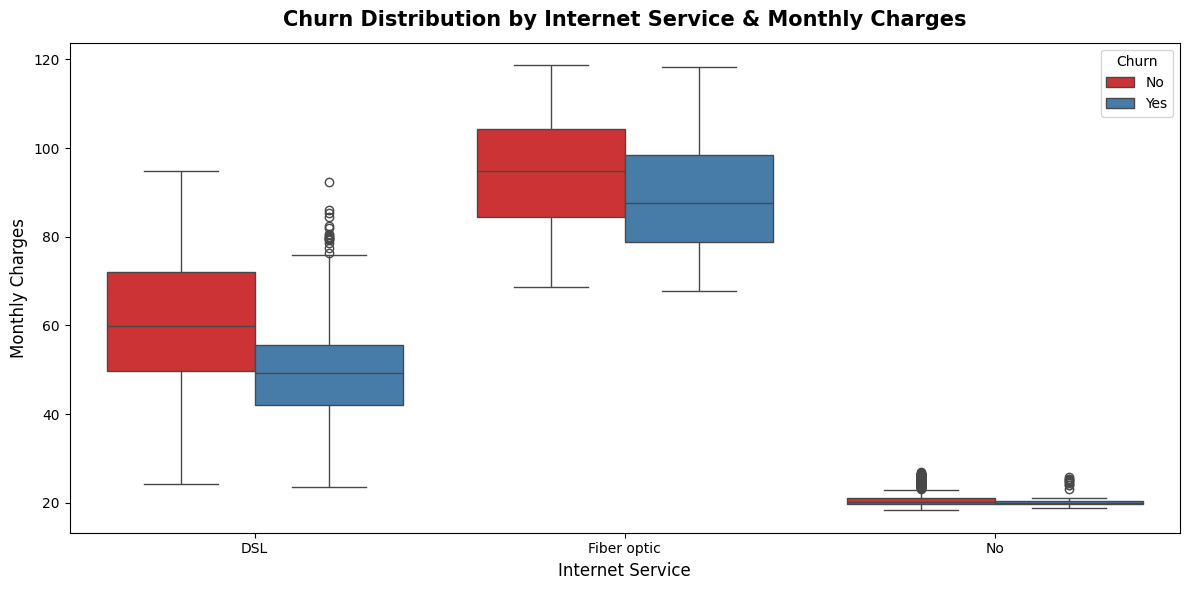

In [108]:
# Plotting the data
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='InternetService' ,y='MonthlyCharges', hue='Churn', palette='Set1')
plt.title('Churn Distribution by Internet Service & Monthly Charges', pad=12, fontsize=15, fontweight='bold')
plt.ylabel('Monthly Charges', fontsize=12)
plt.xlabel('Internet Service', fontsize=12)

plt.tight_layout()
plt.show()

### **Insights**

**Fiber Optic customers with higher monthly charges have higher churn -** Customers with Fiber Optic service and Higher Monthly charges tend to churn more, indicating a potential dissatisfaction with the service or pricing.

**DSL users shows lower churn -** DSL customers tend to have lower monthly charges and exibit a lower churn rate, suggesting satisfaction with the service.

**No Internet Service customers -** Customets with no Internet Service have minimal churn, but ther monthly charges are very low.

### 14. Waht Percentage of customers have Churned Vs Stayed?

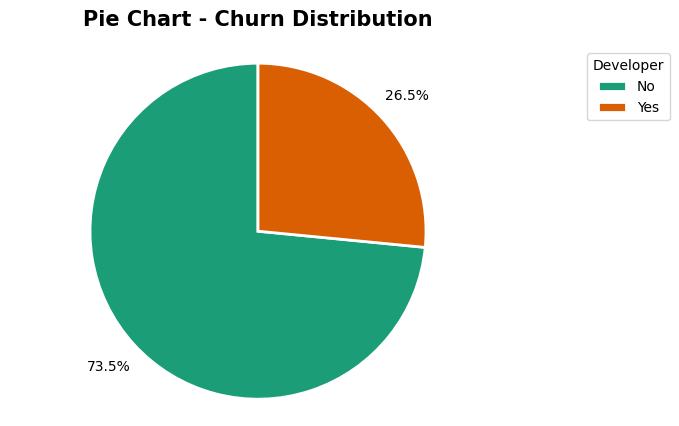

In [113]:
# Plotting the data
df['Churn'].value_counts().plot(kind='pie',
                                startangle=90,
                                autopct='%1.1f%%',
                                labels=None,
                                pctdistance=1.2,
                                colors = plt.cm.Dark2.colors,
                                wedgeprops= {'edgecolor':'white', 'linewidth':2})
plt.title('Pie Chart - Churn Distribution', pad=15, fontsize=15, fontweight='bold')
plt.ylabel('')

plt.axis('equal')
plt.legend(labels=df['Churn'].value_counts().index, bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=10, title='Developer')
#plt.tight_layout()
plt.show()

### **Insights**

**73.5% of Customers have not churned -** A majority of customers are staying with service.

**26.5% of customers have churned -** A significant portion of customers have switched to other providers.

**Focus on Retention -** The company should work on reducing the 26.5% churn rate to improve customer loyalty and revenue stability.

### 15. What are the proportion of customers subscribed to each Internet Service Type(DSL, Fiber Optic, or No Internet Service)?

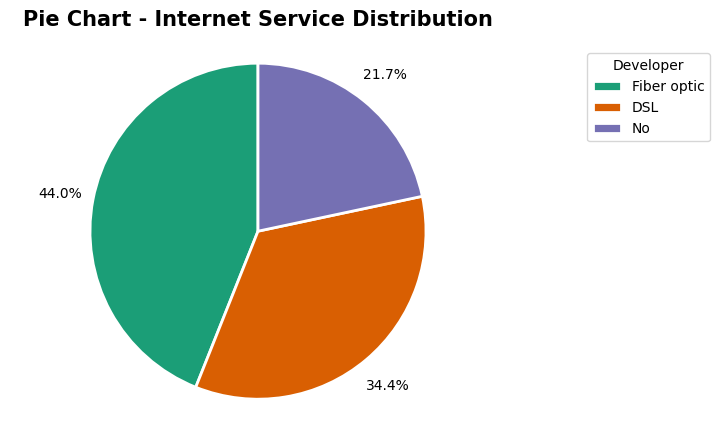

In [114]:
# Plotting the data
df['InternetService'].value_counts().plot(kind='pie',
                                startangle=90,
                                autopct='%1.1f%%',
                                labels=None,
                                pctdistance=1.2,
                                colors = plt.cm.Dark2.colors,
                                wedgeprops= {'edgecolor':'white', 'linewidth':2})
plt.title('Pie Chart - Internet Service Distribution', pad=15, fontsize=15, fontweight='bold')
plt.ylabel('')

plt.axis('equal')
plt.legend(labels=df['InternetService'].value_counts().index, bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=10, title='Developer')
#plt.tight_layout()
plt.show()

### **Insights**

**Fiber Optic is the most popular service -** 44% of customers are using Fiber Optic Internet.

**DSL is the most populat service -** 34.4% of customers are using DSL internet.

**21.7% customers have no Internet Service -** A smaller portion of customers have no internet service